In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
print("Ran Successfully")

Ran Successfully


In [9]:
df = pd.read_csv("credit_score.csv")
df.head()


,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000,Master's Degree,Married,2,Owned,High
2,35,Female,75000,Doctorate,Married,1,Owned,High
3,40,Male,125000,High School Diploma,Single,0,Owned,High
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,High


In [10]:
df = df.select_dtypes(include=[np.number])
df = df.dropna()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 164 non-null    int64
 1   Income              164 non-null    int64
 2   Number of Children  164 non-null    int64
dtypes: int64(3)
memory usage: 4.0 KB


In [11]:
df["CreditScore"] = np.where(df["Income"] > 50000, 1, 0)
df.head()


,Age,Income,Number of Children,CreditScore
0,25,50000,0,0
1,30,100000,2,1
2,35,75000,1,1
3,40,125000,0,1
4,45,100000,3,1


In [12]:
X = df.drop("CreditScore", axis=1)
y = df["CreditScore"]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 131
Testing samples: 33


In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [15]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))


Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.93      1.00      0.96        26

    accuracy                           0.94        33
   macro avg       0.96      0.86      0.90        33
weighted avg       0.94      0.94      0.94        33

Logistic Regression ROC-AUC: 0.9780219780219781


In [16]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))


Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        26

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33

Random Forest ROC-AUC: 1.0


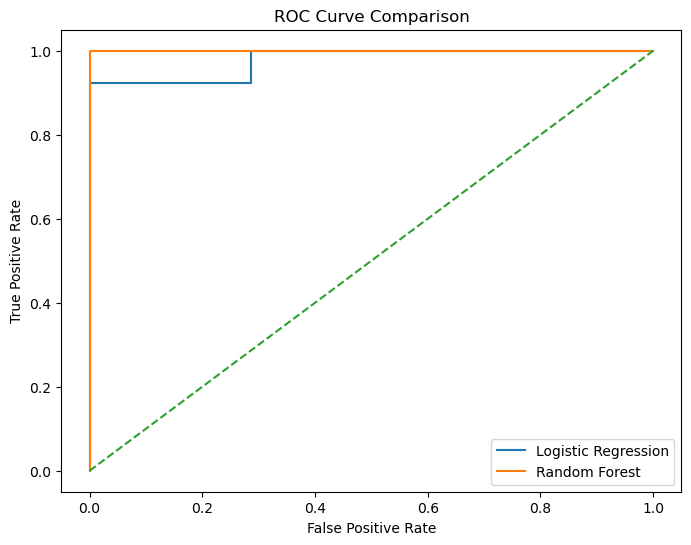

In [17]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
